# AMATH 515 Homework 2

**Due Date: 02/06/2026**

* Name: Justin Chang
* Student Number: 2329407
* Favorite Color: BLUE

*Homework Instruction*: Please follow order of this notebook and fill in the codes where commented as `TODO`.

In [55]:
import numpy as np
import numpy.linalg as LA
import scipy.io as sio
import matplotlib.pyplot as plt

## Please complete the solvers in `solver.py`

In [56]:
import sys

sys.path.append('./')
from solvers import *

## Problem 3: Compressive Sensing

Consier the optimization problem,

$$
\min_x~~\frac{1}{2}\|Ax - b\|^2 + \lambda\|x\|_1
$$

In the following, please specify the $f$ and $g$ and use the proximal gradient descent solver to obtain the solution.

In [57]:
# create the data
np.random.seed(123)
m = 100  # number of measurements
n = 500  # number of variables
k = 10  # number of nonzero variables
s = 0.05  # measurements noise level
#
A_cs = np.random.randn(m, n)
x_cs = np.zeros(n)
x_cs[np.random.choice(range(n), k, replace=False)] = np.random.choice([-1.0, 1.0], k)
b_cs = A_cs.dot(x_cs) + s * np.random.randn(m)
#
lam_cs = 0.1 * norm(A_cs.T.dot(b_cs), np.inf)

In [58]:
# define the function, prox and the beta constant
def func_f_cs(x):
    f = 0.5 * (LA.norm(A_cs @ x - b_cs, 2)) ** 2
    return f


def func_g_cs(x):
    g = lam_cs * LA.norm(x, 1)
    return g


def grad_f_cs(x):
    grad = A_cs.T @ (A_cs @ x - b_cs)
    return grad


def prox_g_cs(z, t):
    ## z is the gradient step
    ## t = 1/ beta
    x_kp1 = np.zeros_like(z)
    for i in range(len(z)):
        if z[i] > t * lam_cs:
            x_kp1[i] = z[i] - t * lam_cs
        elif np.abs(z[i]) <= t * lam_cs:
            x_kp1[i] = 0
        else:
            x_kp1[i] = t * lam_cs + z[i]

    return x_kp1


# TODO: complete the prox of 1 norm

##==GRADED==##
# TODO: what is the beta value for the smooth part
beta_f_cs = LA.norm(A_cs.T @ A_cs, 2)

In [59]:
##==GRADED==##
cs_test_dot = np.ones(n)

# Should be a number
func_cs_test = func_f_cs(cs_test_dot) + func_g_cs(cs_test_dot)

# Should be a numpy vector of shape (n, )
grad_f_cs_test = grad_f_cs(cs_test_dot)

# Should be a numpy vector of shape (n, )
prox_g_cs_test = prox_g_cs(cs_test_dot, 1)

### Proximal gradient descent on compressive sensing

In [60]:
# apply the proximal gradient descent solver
x0_cs_pgd = np.zeros(x_cs.size)
x_cs_pgd, obj_his_cs_pgd, err_his_cs_pgd, exit_flag_cs_pgd = optimizeWithPGD(x0_cs_pgd, func_f_cs, func_g_cs, grad_f_cs,
                                                                             prox_g_cs, beta_f_cs)

solver begin
295.2914318634954
254.62467586651906
235.66362207976414
224.3792437039603
216.41364375553104
210.44546306681764
205.80629505515506
201.9580254143113
198.77636959664142
195.98891263555583
193.44477266880853
191.13020253276068
189.03386614396962
187.11129609109236
185.33161127049365
183.6627762639892
182.09799180876473
180.64105345186533
179.28406652082614
178.0301251663937
176.8354857602206
175.68700216846122
174.5824593022792
173.54022167611927
172.53516323279854
171.5698451524399
170.6486451304034
169.7711747339519
168.92646011456264
168.10508354344688
167.3027879187592
166.52150316919207
165.75736541019646
165.00934412941166
164.27799595678698
163.56319043454255
162.86836570189922
162.19120929641844
161.5287769107519
160.87947899561686
160.24524511762831
159.6360288501591
159.0456668954689
158.47184142955638
157.91773852105766
157.37906025506422
156.85350748466072
156.3443323046667
155.8491727626315
155.36678600667048
154.90284134280208
154.45026395939115
154.00915149964

Text(0.5, 1.0, 'Compressive Sensing Signal')

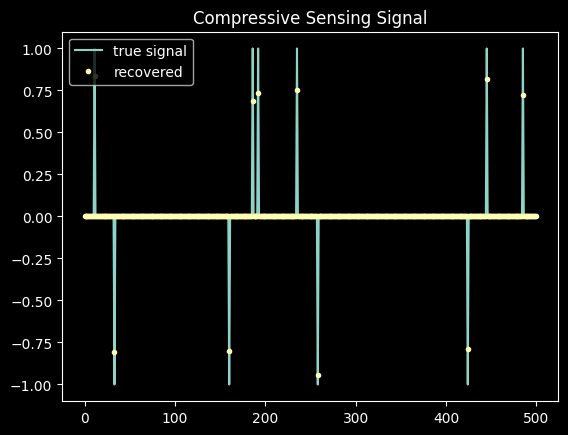

In [61]:
# plot signal result
plt.plot(x_cs)
plt.plot(x_cs_pgd, '.')
plt.legend(['true signal', 'recovered'])
plt.title('Compressive Sensing Signal')

Text(0.5, 0.98, 'Proximal Gradient Descent on Compressive Sensing')

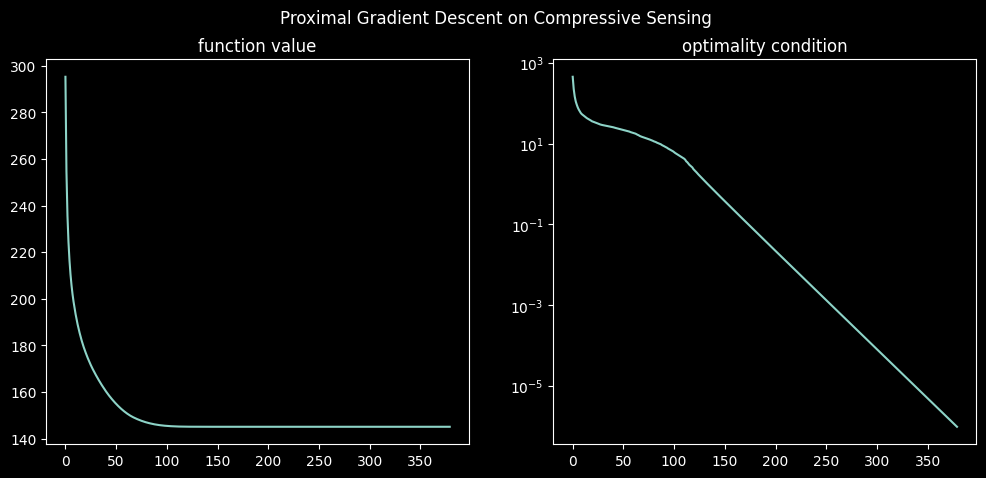

In [62]:
# plot result
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(obj_his_cs_pgd)
ax[0].set_title('function value')
ax[1].semilogy(err_his_cs_pgd)
ax[1].set_title('optimality condition')
fig.suptitle('Proximal Gradient Descent on Compressive Sensing')

### Accelerate proximal gradient descent on compressive sensing

In [63]:
# apply the proximal gradient descent solver
x0_cs_apgd = np.zeros(x_cs.size)
x_cs_apgd, obj_his_cs_apgd, err_his_cs_apgd, exit_flag_cs_apgd = \
    optimizeWithAPGD(x0_cs_apgd, func_f_cs, func_g_cs, grad_f_cs, prox_g_cs, beta_f_cs)

295.2914318634954
254.62467586651906
231.50720198876246
217.00099240646853
206.7078234336156
198.97538991576675
192.67097785232244
187.09985673426826
182.20255873640235
177.8982735431144
174.04013949320154
170.45352634004416
167.1332586336685
163.88030837390363
160.8001835394435
157.9942761583773
155.4345205997693
153.05634073150296
150.91350689581958
149.19292836158252
147.8594615372436
146.83062867031995
146.08348358048497
145.5555181265122
145.32802342161497
145.32451765227583
145.4319558542807
145.55153756003526
145.64017236340518
145.67702083204338
145.65852556254939
145.59330562751583
145.4973019670854
145.38923470883776
145.2866077429682
145.20268487118236
145.1448156725791
145.1142240949042
145.10704427484123
145.11614778624107
145.13322539370364
145.15064746450102
145.16279168924342
145.1666582724165
145.16182505832361
145.1500042721753
145.13410457294032
145.11736876716785
145.1025958412852
145.09163982712508
145.0852247047213
145.083043690628
145.08405554847693
145.086867067

Text(0.5, 1.0, 'Compressive Sensing Signal')

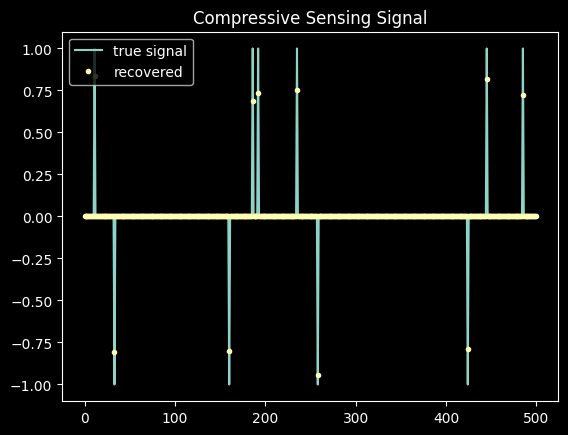

In [64]:
# plot signal result
plt.plot(x_cs)
plt.plot(x_cs_pgd, '.')
plt.legend(['true signal', 'recovered'])
plt.title('Compressive Sensing Signal')

Text(0.5, 0.98, 'Accelerated Proximal Gradient Descent on Compressive Sensing')

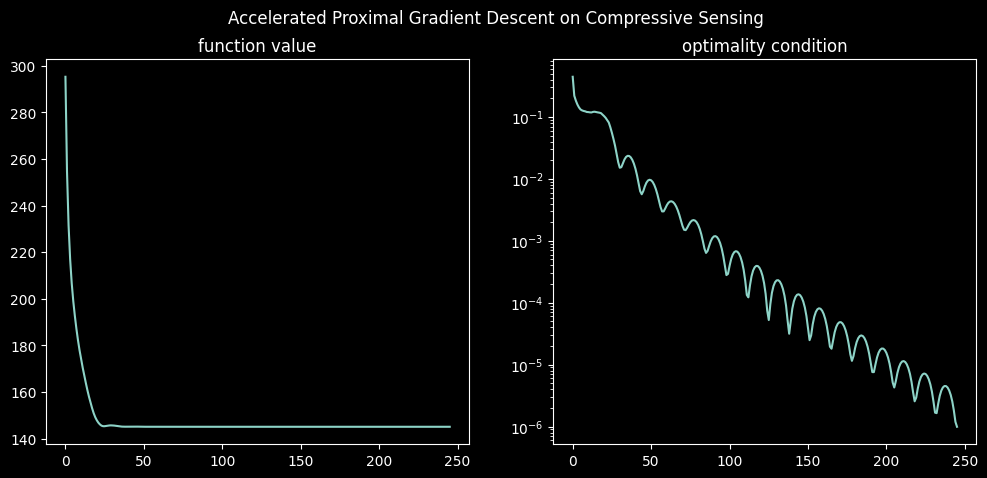

In [65]:
# plot result
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(obj_his_cs_apgd)
ax[0].set_title('function value')
ax[1].semilogy(err_his_cs_apgd)
ax[1].set_title('optimality condition')
fig.suptitle('Accelerated Proximal Gradient Descent on Compressive Sensing')

## Problem 4: Logistic Regression on MNIST Data

Now let's play with some real data, recall the logistic regression problem,

$$
\min_x~~\sum_{i=1}^m\left\{\log(1 + \exp(\langle a_i,x \rangle)) - b_i\langle a_i,x \rangle\right\} + \frac{\lambda}{2}\|x\|^2.
$$

Here our data pair $\{a_i, b_i\}$, $a_i$ is the image and $b_i$ is the label.
In this homework problem, let's consider the binary classification problem, where $b_i \in \{0, 1\}$.

In [66]:
# import data
mnist_data = np.load('mnist01.npy', allow_pickle=True)
#
A_lgt = mnist_data[0]
b_lgt = mnist_data[1]
A_lgt_test = mnist_data[2]
b_lgt_test = mnist_data[3]
#
# set regularizer parameter
lam_lgt = 0.1
#
# beta constant of the function
beta_lgt = 0.25 * norm(A_lgt, 2) ** 2 + lam_lgt


# define accuracy function
def accuracy(x, A_test, b_test):
    r = A_test.dot(x)
    b_test[b_test == 0.0] = -1.0
    correct_count = np.sum((r * b_test) > 0.0)
    return correct_count / b_test.size

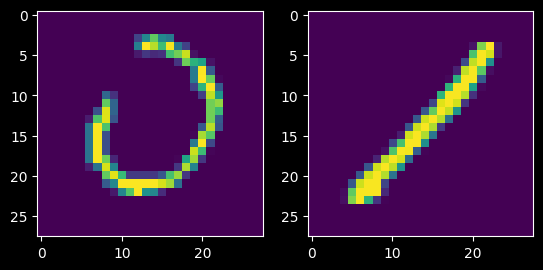

In [67]:
# plot the images
fig, ax = plt.subplots(1, 2)
ax[0].imshow(A_lgt[0].reshape(28, 28))
ax[1].imshow(A_lgt[7].reshape(28, 28))

In [68]:
# implement logistic function, gradient and Hessian
def lgt_func(x):
    #####
    f = lam_lgt / 2 * LA.norm(x, 2) ** 2
    for i in range(len(A_lgt[:,0])):
        a_i = A_lgt[i]
        b_i = b_lgt[i]
        f += np.log(1 + np.exp(a_i.T @ x))  ## the log term
        f -= b_i * a_i.T @ x  ## the inner product term
    #####
    return f


def sig(Ax_i):
    return np.exp(Ax_i) / (1 + np.exp(Ax_i))


#
def lgt_grad(x):
    #####
    Ax = A_lgt @ x
    grad = -A_lgt.T @ b_lgt
    sigmas = np.zeros(len(Ax))
    for i in range(len(Ax)):
        sigmas[i] = sig(Ax[i])
    grad += A_lgt.T @ sigmas
    grad += lam_lgt * x
    #####
    return grad


#
def lgt_hess(x):
    #####
    H = lam_lgt * np.eye(len(A_lgt[0]))
    Ax = A_lgt @ x
    sigmas = np.zeros([len(Ax), 1])
    for i in range(len(Ax)):
        sigmas[i] = sig(Ax[i])
    H_yy = np.diag(sigmas @ (np.ones([len(Ax), 1]) - sigmas).T)
    H_yy = np.diag(H_yy)
    H += A_lgt.T @ H_yy @ A_lgt

    #####
    return H

### Gradient descent on logistic regression

In [79]:
# apply the gradient descent
x0_lgt_gd = np.zeros(A_lgt.shape[1])
x_lgt_gd, obj_his_lgt_gd, err_his_lgt_gd, exit_flag_lgt_gd = \
    optimizeWithGD(x0_lgt_gd, lgt_func, lgt_grad, beta_lgt)

Gradient descent reach maximum number of iteration.


accuracy of the result is 1.000


Text(0.5, 0.98, 'Gradient Descent on Logistic Regression')

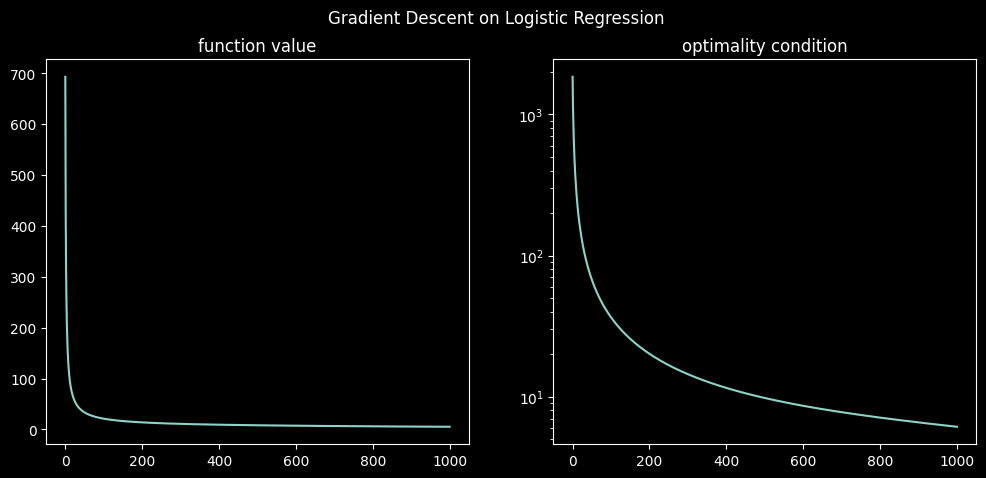

In [70]:
print('accuracy of the result is %0.3f' % accuracy(x_lgt_gd, A_lgt_test, b_lgt_test))
# plot result
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(obj_his_lgt_gd)
ax[0].set_title('function value')
ax[1].semilogy(err_his_lgt_gd)
ax[1].set_title('optimality condition')
fig.suptitle('Gradient Descent on Logistic Regression')

### Accelerate Gradient decsent on logistic regression

In [78]:
# apply the accelerated gradient descent
x0_lgt_agd = np.zeros(A_lgt.shape[1])
x_lgt_agd, obj_his_lgt_agd, err_his_lgt_agd, exit_flag_lgt_agd = \
    optimizeWithAGD(x0_lgt_agd, lgt_func, lgt_grad, beta_lgt)

Proximal gradient descent reach maximum of iteration


accuracy of the result is 1.000


Text(0.5, 0.98, 'Accelerated Gradient Descent on Logistic Regression')

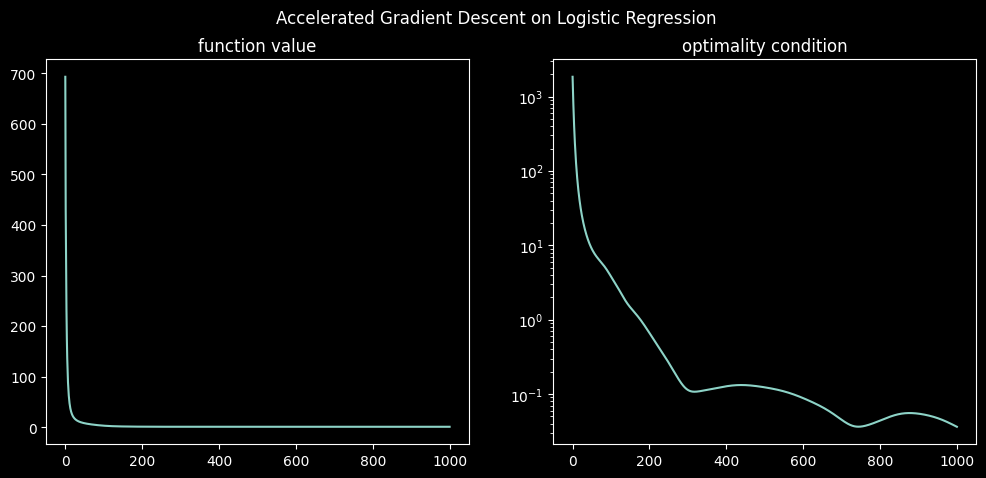

In [72]:
print('accuracy of the result is %0.3f' % accuracy(x_lgt_agd, A_lgt_test, b_lgt_test))
# plot result
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(obj_his_lgt_agd)
ax[0].set_title('function value')
ax[1].semilogy(err_his_lgt_agd)
ax[1].set_title('optimality condition')
fig.suptitle('Accelerated Gradient Descent on Logistic Regression')

### Newton Method on logistic regression

In [84]:
# apply the accelerated gradient descent
x0_lgt_nt = np.zeros(A_lgt.shape[1])
x_lgt_nt, obj_his_lgt_nt, err_his_lgt_nt, exit_flag_lgt_nt = \
    optimizeWithNT(x0_lgt_nt, lgt_func, lgt_grad, lgt_hess)

accuracy of the result is 1.000


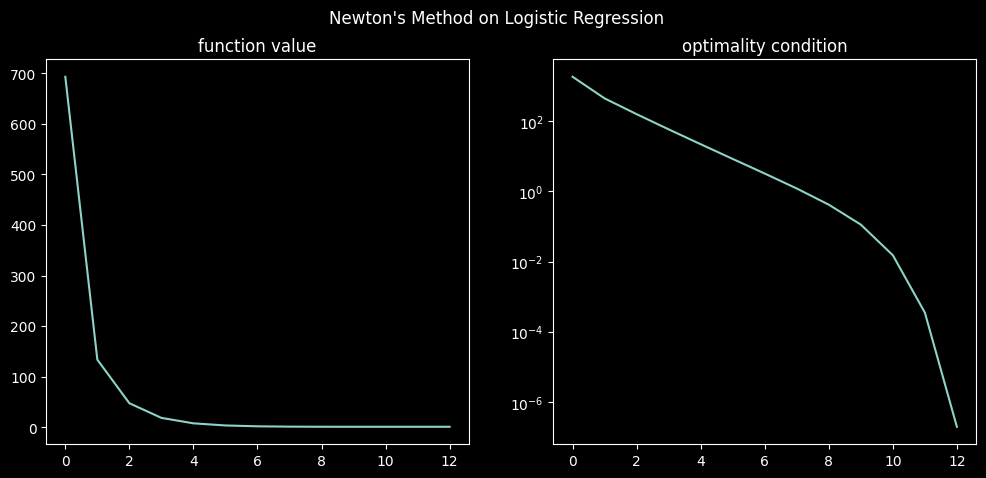

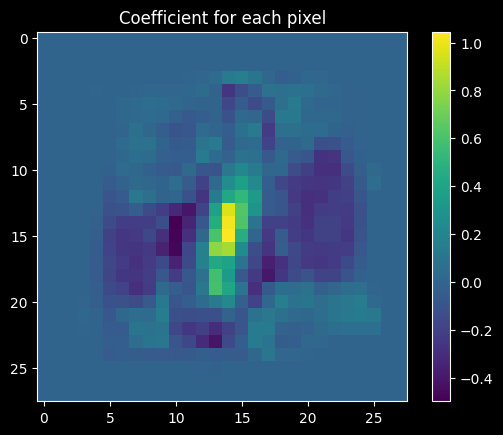

In [82]:
print('accuracy of the result is %0.3f' % accuracy(x_lgt_nt, A_lgt_test, b_lgt_test))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(obj_his_lgt_nt)
ax[0].set_title('function value')
ax[1].semilogy(err_his_lgt_nt)
ax[1].set_title('optimality condition')
fig.suptitle('Newton\'s Method on Logistic Regression')

plt.show()
plt.title("Coefficient for each pixel")
plt.imshow(x_lgt_nt.reshape(28, 28))
plt.colorbar()
plt.show()

## We can combine the compressed sensing (lasso) regularizer with the logistic regression objective to get a sparse classifier

493.4133360003992
405.76953613779835
344.2878847822501
303.76091090479196
277.5637079568375
260.5392624969637
249.26085919914212
241.57711780511653
236.14125407098453
232.19964464292562
229.0596874038995
226.55943377116034
224.59025114782574
222.78480839731301
221.0802368467115
219.4923705793724
218.19642508389467
217.027980422643
215.82799726090326
214.77136017710808
213.90306263843885
212.98568246631675
212.0179650092348
211.1570882954516
210.37191963578732
209.58306760188776
208.78643114930406
207.97955715972972
207.21775433944126
206.49779367086478
205.80920109826343
205.28330858325734
204.678027450973
203.97347547291577
203.4118969013023
202.91775738838732
202.43862895474902
201.96456988371608
201.7385905679016
201.46979353202767
201.07292252237016
200.76364371682604
200.54163148298642
200.31331339328773
200.08571383110188
199.85686442075294
199.6334370879579
199.40735380863114
199.17576586104497
198.93795657233116
198.69427185504352
198.45042462101594
198.205341867173
197.9601193

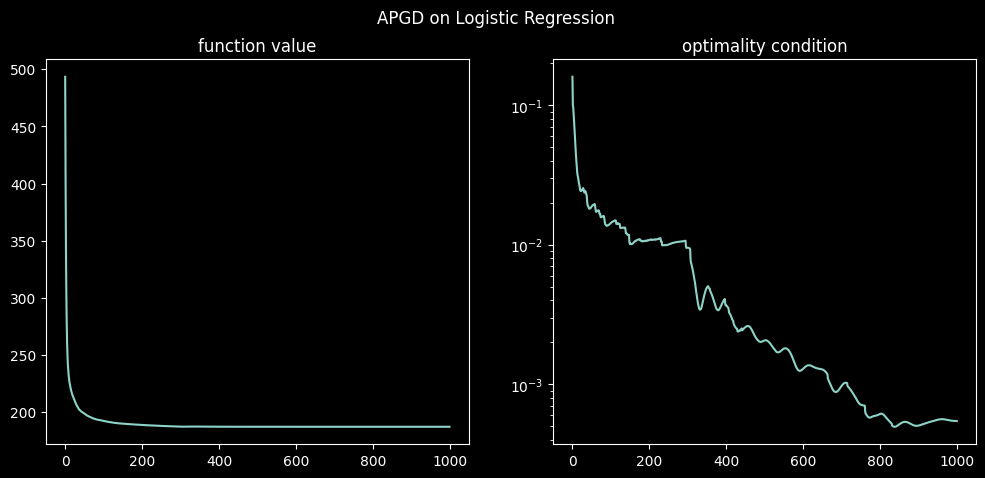

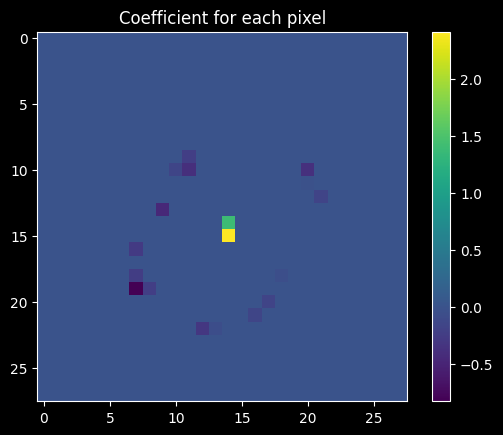

In [75]:
# apply the proximal gradient descent solver
x0_mnist_pgd = np.zeros(A_lgt.shape[1])
x_mnist_pgd, obj_his_mnist_apgd, err_his_mnist_apgd, exit_flag_mnist_pgd = \
    optimizeWithAPGD(x0_mnist_pgd, lgt_func, func_g_cs, lgt_grad, prox_g_cs, beta_lgt)

print(f"Classifying looking at {np.sum(x_mnist_pgd != 0)} nonzero entries")
print('accuracy of the result is %0.3f' % accuracy(x_lgt_nt, A_lgt_test, b_lgt_test))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(obj_his_mnist_apgd)
ax[0].set_title('function value')
ax[1].semilogy(err_his_mnist_apgd)
ax[1].set_title('optimality condition')
fig.suptitle('APGD on Logistic Regression')
plt.show()

plt.title("Coefficient for each pixel")
plt.imshow(x_mnist_pgd.reshape(28, 28))
plt.colorbar()
plt.show()
